In [12]:
import pandas as pd

df = pd.read_csv("../data/raw/telco_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../data/raw/telco_customer_churn.csv")


In [15]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [20]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

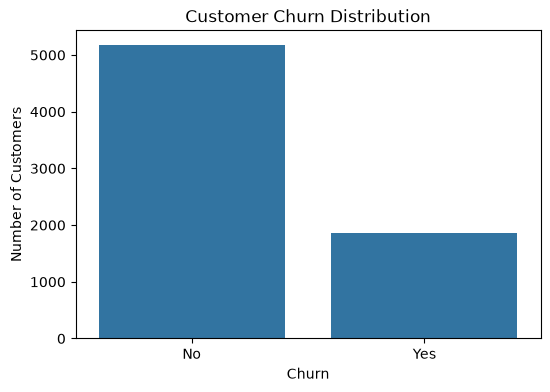

Churn by Gender:
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

Churn by Contract:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

Churn by Internet Service:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

Churn by Tenure:
Churn                No        Yes
tenure_group                      
0-12 months   52.321839  47.678161
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176

Churn by Payment Method:
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.24310

In [21]:
# 1. Customer Churn Distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


# 2. Churn by Gender
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn by Gender:")
print(gender_churn)


# 3. Churn by Contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn by Contract:")
print(contract_churn)


# 4. Churn by Internet Service
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn by Internet Service:")
print(internet_churn)


# 5. Create Tenure Groups
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn by Tenure:")
print(tenure_churn)


# 6. Churn by Payment Method
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn by Payment Method:")
print(payment_churn)


# 7. Monthly Charges by Churn
print("\nMonthly Charges by Churn:")
print(
    df.groupby("Churn")["MonthlyCharges"].agg(
        ["mean", "median", "min", "max"]
    )
)


# 8. Total Charges by Churn
print("\nTotal Charges by Churn:")
print(
    df.groupby("Churn")["TotalCharges"].agg(
        ["mean", "median", "min", "max"]
    )
)

In [ ]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
tenure_group        11
dtype: int64

In [ ]:


df.duplicated().sum()

np.int64(0)

In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df.dtypes

customerID               str
gender                   str
SeniorCitizen          int64
Partner                  str
Dependents               str
tenure                 int64
PhoneService             str
MultipleLines            str
InternetService          str
OnlineSecurity           str
OnlineBackup             str
DeviceProtection         str
TechSupport              str
StreamingTV              str
StreamingMovies          str
Contract                 str
PaperlessBilling         str
PaymentMethod            str
MonthlyCharges       float64
TotalCharges             str
Churn                    str
tenure_group        category
dtype: object

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.5,No,25-48 months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months


In [ ]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

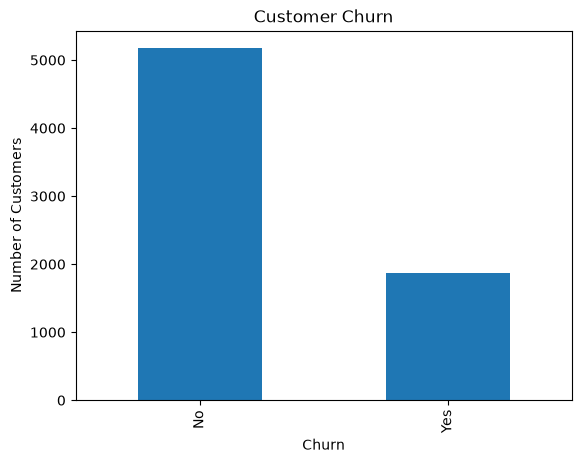

In [ ]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [ ]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [ ]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [ ]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df["tenure_group"].value_counts().sort_index()


tenure_group
0-12 months     2175
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [ ]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df["tenure_group"].value_counts().sort_index()

tenure_group
0-12 months     2175
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

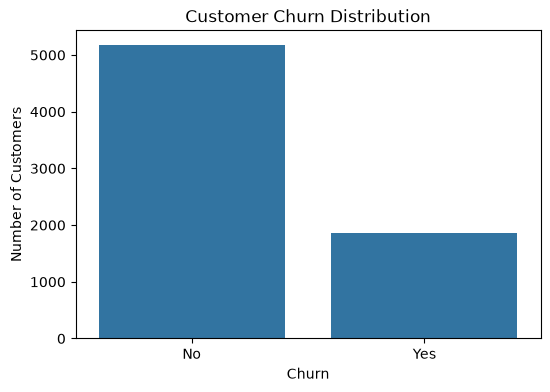

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
Churn                No        Yes
tenure_group                      
0-12 months   52.321839  47.678161
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700
           

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()
gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print(gender_churn)
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

print(tenure_churn)
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(payment_churn)
print(
    df.groupby("Churn")["MonthlyCharges"].agg(
        ["mean", "median", "min", "max"]
    )
)
print(
    df.groupby("Churn")["TotalCharges"].agg(
        ["mean", "median", "min", "max"]
    )
)


In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
print(
    df.groupby("Churn")["TotalCharges"].agg(
        ["mean", "median", "min", "max"]
    )
)

              mean   median    min      max
Churn                                      
No     2555.344141  1683.60  18.80  8672.45
Yes    1531.796094   703.55  18.85  8684.80


In [ ]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [ ]:
# ============================================
# DATA CLEANING & FEATURE ENGINEERING
# ============================================

# 1. Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# 2. Check missing values created during conversion
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

# 3. Fill missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 4. Convert Churn into a numeric target
# No = 0, Yes = 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# 5. Remove customerID
# It is an identifier, not a useful predictive feature
df = df.drop(columns=["customerID"])

# 6. Create a simple tenure group
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

# 7. Convert categorical columns into dummy/indicator variables
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

# 8. Display the cleaned dataset
print("\nCleaned dataset shape:")
print(df_encoded.shape)

print("\nFirst 5 rows:")
display(df_encoded.head())

# 9. Check that there are no missing values
print("\nRemaining missing values:")
print(df_encoded.isnull().sum().sum())

Missing TotalCharges: 11

Cleaned dataset shape:
(7043, 34)

First 5 rows:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24 months,tenure_group_25-48 months,tenure_group_49-72 months
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,False
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,True,False,False,False,False,False,False,True,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False



Remaining missing values:
0


In [ ]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Split data into training and testing sets
# stratify=y keeps the churn proportion similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True))

Training data shape: (5634, 33)
Testing data shape: (1409, 33)

Training churn distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [17]:
# ============================================
# MODEL EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Probability of churn
y_probability = logistic_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Model Performance")
print("=================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Performance
Accuracy : 0.7984
Precision: 0.6500
Recall   : 0.5214
F1 Score : 0.5786
ROC-AUC  : 0.8423

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[930 105]
 [179 195]]


In [ ]:
# ============================================
# COMPLETE MODEL SETUP + TRAINING
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Separate features and target
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create Logistic Regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train model
logistic_model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Model trained successfully!
Training rows: 5634
Testing rows: 1409


In [ ]:
# ============================================================
# RESTORE COMPLETE CHURN ML PIPELINE
# PREPROCESSING + TRAIN/TEST SPLIT + LOGISTIC REGRESSION
# + MODEL EVALUATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD RAW DATASET
# ============================================================

file_path = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")


# ============================================================
# 2. DATA PREPROCESSING
# ============================================================

# Convert TotalCharges from object/string to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Fill missing TotalCharges values
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Convert Churn from Yes/No to 1/0
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Remove customerID because it is only an identifier
df = df.drop(columns=["customerID"])


# ============================================================
# 3. CREATE TENURE GROUP
# ============================================================

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)


# ============================================================
# 4. ONE-HOT ENCODING
# ============================================================

df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

print("\nPreprocessing completed.")
print(f"Encoded dataset shape: {df_encoded.shape}")


# ============================================================
# 5. CREATE FEATURES AND TARGET
# ============================================================

X = df_encoded.drop(
    columns=["Churn"]
)

y = df_encoded["Churn"]


# ============================================================
# 6. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain/Test split completed.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")


# ============================================================
# 7. CREATE LOGISTIC REGRESSION MODEL
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# ============================================================
# 8. TRAIN LOGISTIC REGRESSION
# ============================================================

logistic_model.fit(
    X_train,
    y_train
)

print("\nLogistic Regression trained successfully.")


# ============================================================
# 9. MAKE PREDICTIONS
# ============================================================

y_pred = logistic_model.predict(
    X_test
)

y_probability = logistic_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 10. CALCULATE PERFORMANCE METRICS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


# ============================================================
# 11. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n")
print("=" * 60)
print("LOGISTIC REGRESSION - MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION PIPELINE RESTORED SUCCESSFULLY")
print("=" * 60)

Dataset loaded successfully.
Dataset shape: (7043, 21)

Preprocessing completed.
Encoded dataset shape: (7043, 34)

Train/Test split completed.
Training samples: 5634
Testing samples : 1409

Logistic Regression trained successfully.


LOGISTIC REGRESSION - MODEL PERFORMANCE
Accuracy : 0.7984
Precision: 0.6500
Recall   : 0.5214
F1 Score : 0.5786
ROC-AUC  : 0.8423

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[930 105]
 [179 195]]

LOGISTIC REGRESSION PIPELINE RESTORED SUCCESSFULLY


In [ ]:
# ============================================================
# RESTORE + TRAIN + EVALUATE LOGISTIC REGRESSION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. CREATE X AND y
# ============================================================

X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]


# ============================================================
# 2. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split completed.")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")


# ============================================================
# 3. CREATE LOGISTIC REGRESSION PIPELINE
# ============================================================

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


# ============================================================
# 4. TRAIN MODEL
# ============================================================

logistic_model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")


# ============================================================
# 5. MAKE PREDICTIONS
# ============================================================

y_pred = logistic_model.predict(X_test)

y_probability = logistic_model.predict_proba(X_test)[:, 1]


# ============================================================
# 6. CALCULATE METRICS
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)


# ============================================================
# 7. DISPLAY MODEL PERFORMANCE
# ============================================================

print("\n")
print("MODEL PERFORMANCE")
print("=================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ============================================================
# 8. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

NameError: name 'df_encoded' is not defined

In [ ]:
# ============================================
# EVALUATE LOGISTIC REGRESSION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = logistic_model.predict(X_test)

# Churn probabilities
y_probability = logistic_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Model Performance")
print("=================")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

NameError: name 'logistic_model' is not defined


Logistic Regression
Accuracy : 0.7984
Precision: 0.6500
Recall   : 0.5214
F1 Score : 0.5786
ROC-AUC  : 0.8423

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[930 105]
 [179 195]]

Decision Tree
Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
ROC-AUC  : 0.8267

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

Confusion Matrix:
[[917 118]
 [172 202]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7984,0.6500,0.5214,0.5786,0.8423
1,Decision Tree,0.7942,0.6312,0.5401,0.5821,0.8267
2,Random Forest,0.8048,0.6667,0.5294,0.5902,0.8450



BEST MODEL
Best Model : Random Forest
ROC-AUC    : 0.8450


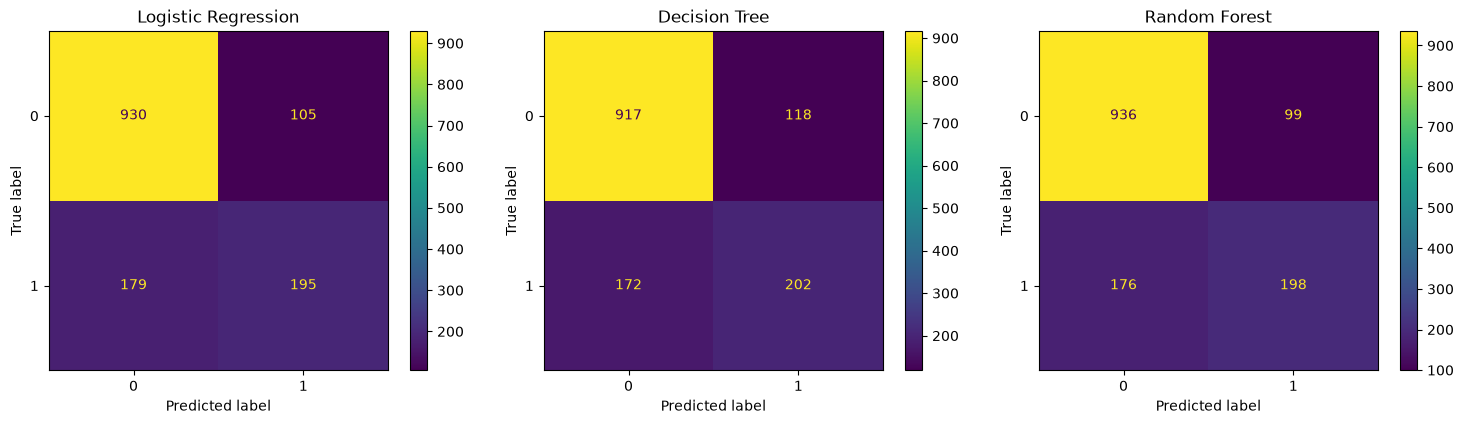

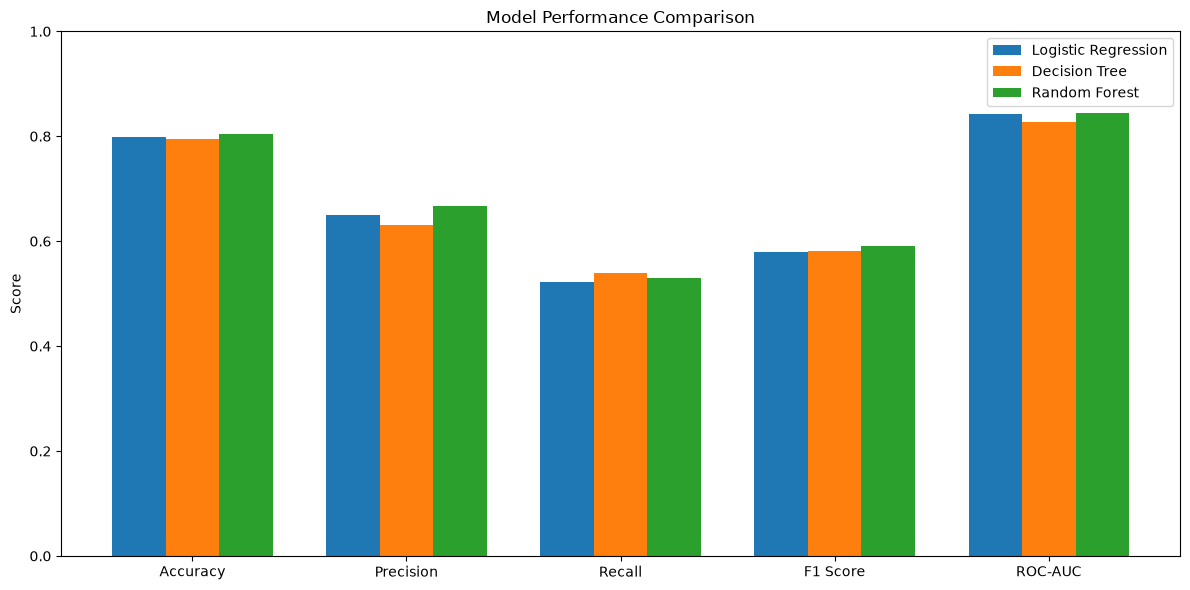


RANDOM FOREST - FEATURE IMPORTANCE


,Feature,Importance
1,tenure,0.156077
3,TotalCharges,0.149669
2,MonthlyCharges,0.104127
10,InternetService_Fiber optic,0.082990
28,PaymentMethod_Electronic check,0.063168
25,Contract_Two year,0.054857
32,tenure_group_49-72 months,0.045190
24,Contract_One year,0.034959
13,OnlineSecurity_Yes,0.024909
26,PaperlessBilling_Yes,0.023633


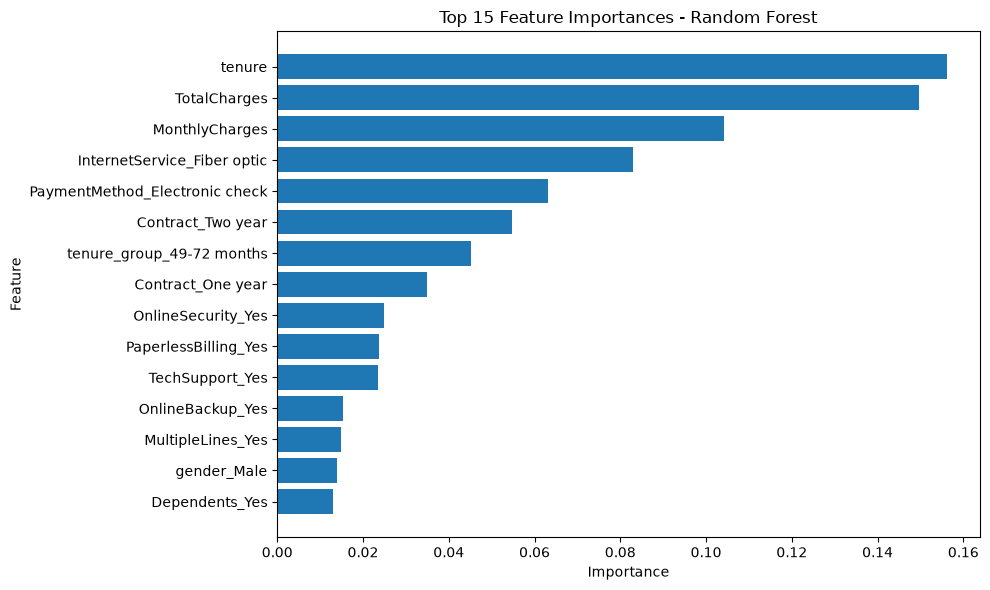

In [18]:
# ============================================================
# MODEL COMPARISON
# Logistic Regression vs Decision Tree vs Random Forest
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Train Decision Tree
# ------------------------------------------------------------

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)

dt_predictions = decision_tree_model.predict(X_test)
dt_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 2. Train Random Forest
# ------------------------------------------------------------

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]


# ------------------------------------------------------------
# 3. Evaluation Function
# ------------------------------------------------------------

def evaluate_model(model_name, y_true, predictions, probabilities):

    accuracy = accuracy_score(y_true, predictions)
    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_true, probabilities)

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, predictions, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, predictions))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


# ------------------------------------------------------------
# 4. Evaluate All Models
# ------------------------------------------------------------

results = []

# Logistic Regression
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

# Decision Tree
results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        dt_predictions,
        dt_probabilities
    )
)

# Random Forest
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)


# ------------------------------------------------------------
# 5. Create Comparison DataFrame
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    results_df.style
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 6. Find Best Model
# ------------------------------------------------------------

best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

best_roc_auc = results_df["ROC-AUC"].max()

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Best Model : {best_model_name}")
print(f"ROC-AUC    : {best_roc_auc:.4f}")


# ------------------------------------------------------------
# 7. Plot Confusion Matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions,
    ax=axes[1]
)
axes[1].set_title("Decision Tree")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    ax=axes[2]
)
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Metric Comparison Plot
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

for i, model_name in enumerate(results_df["Model"]):
    values = results_df.loc[
        results_df["Model"] == model_name,
        metrics
    ].values[0]

    plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model_name
    )

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. Feature Importance - Random Forest
# ------------------------------------------------------------

if hasattr(X_train, "columns"):

    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": random_forest_model.feature_importances_
    }).sort_values(
        by="Importance",
        ascending=False
    )

    print("\n" + "=" * 60)
    print("RANDOM FOREST - FEATURE IMPORTANCE")
    print("=" * 60)

    display(feature_importance)

    plt.figure(figsize=(10, 6))

    top_features = feature_importance.head(15).sort_values(
        "Importance"
    )

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top 15 Feature Importances - Random Forest")
    plt.tight_layout()
    plt.show()

else:
    print(
        "\nFeature importance plot skipped because "
        "X_train does not contain column names."
    )


Logistic Regression
Accuracy : 0.7984
Precision: 0.6500
Recall   : 0.5214
F1 Score : 0.5786
ROC-AUC  : 0.8423

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[930 105]
 [179 195]]

Decision Tree
Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
ROC-AUC  : 0.8272

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409

Confusion Matrix:
[[917 118]
 [172 202]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7984,0.6500,0.5214,0.5786,0.8423
1,Decision Tree,0.7942,0.6312,0.5401,0.5821,0.8272
2,Random Forest,0.8048,0.6667,0.5294,0.5902,0.8450



BEST MODEL BASED ON ROC-AUC
Model   : Random Forest
ROC-AUC : 0.8450


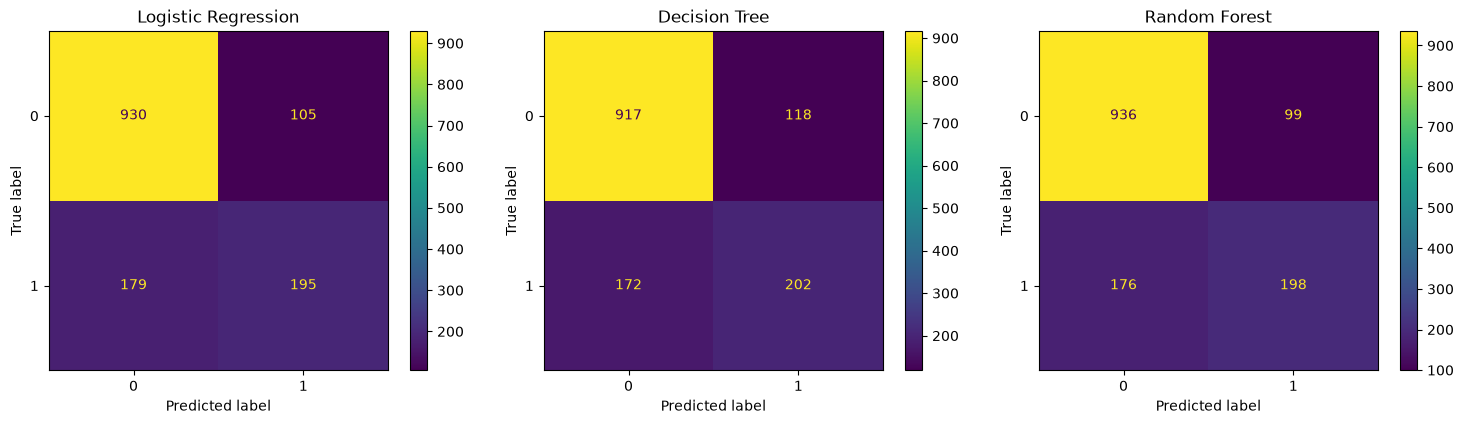

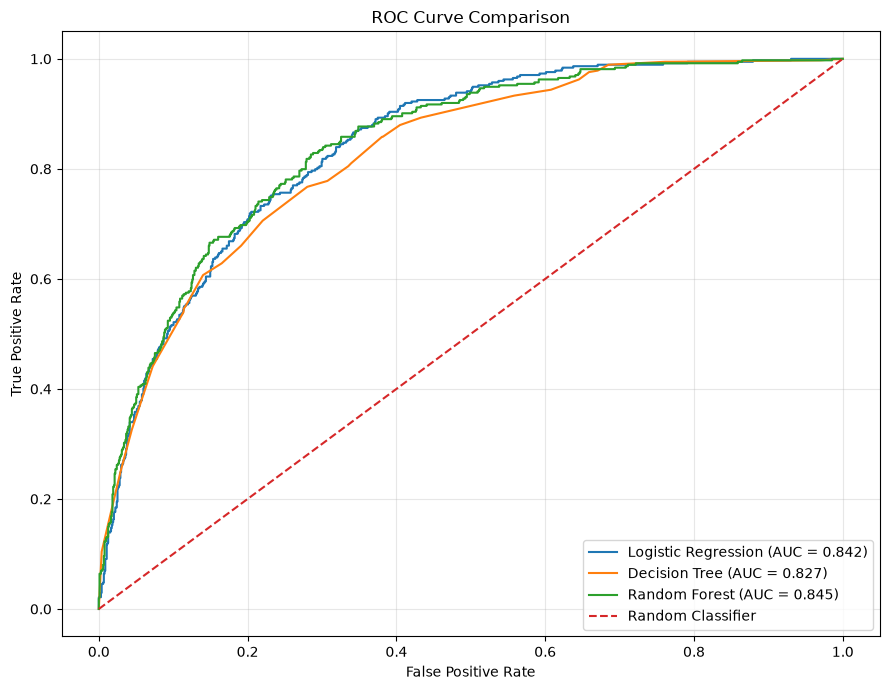

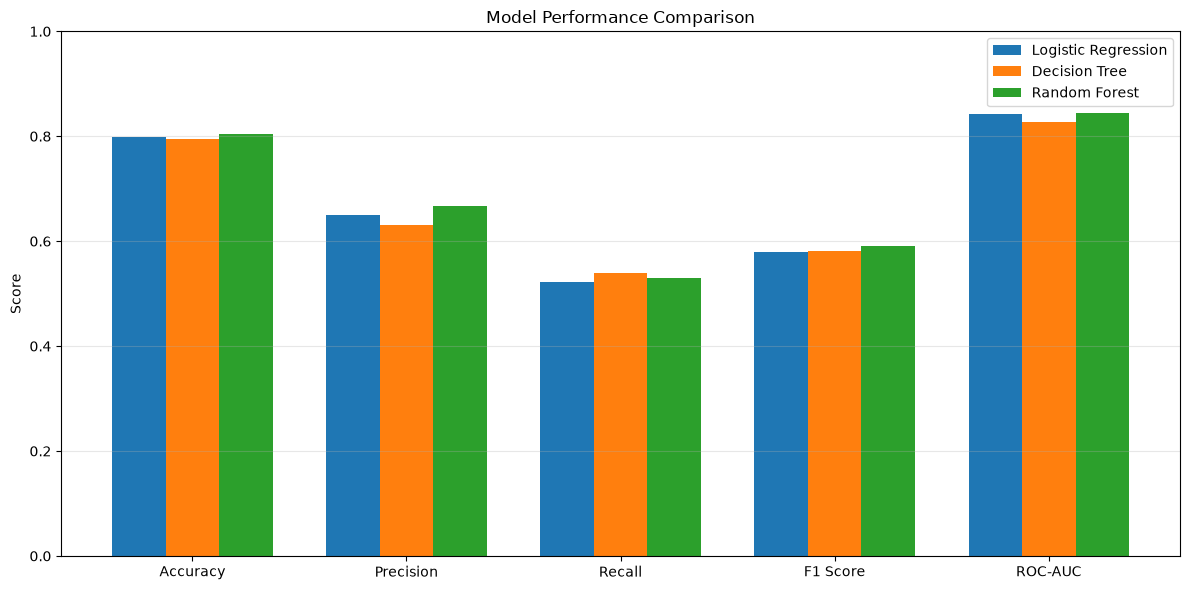


TOP 15 RANDOM FOREST FEATURES


,Feature,Importance
0,tenure,0.156077
1,TotalCharges,0.149669
2,MonthlyCharges,0.104127
3,InternetService_Fiber optic,0.082990
4,PaymentMethod_Electronic check,0.063168
5,Contract_Two year,0.054857
6,tenure_group_49-72 months,0.045190
7,Contract_One year,0.034959
8,OnlineSecurity_Yes,0.024909
9,PaperlessBilling_Yes,0.023633


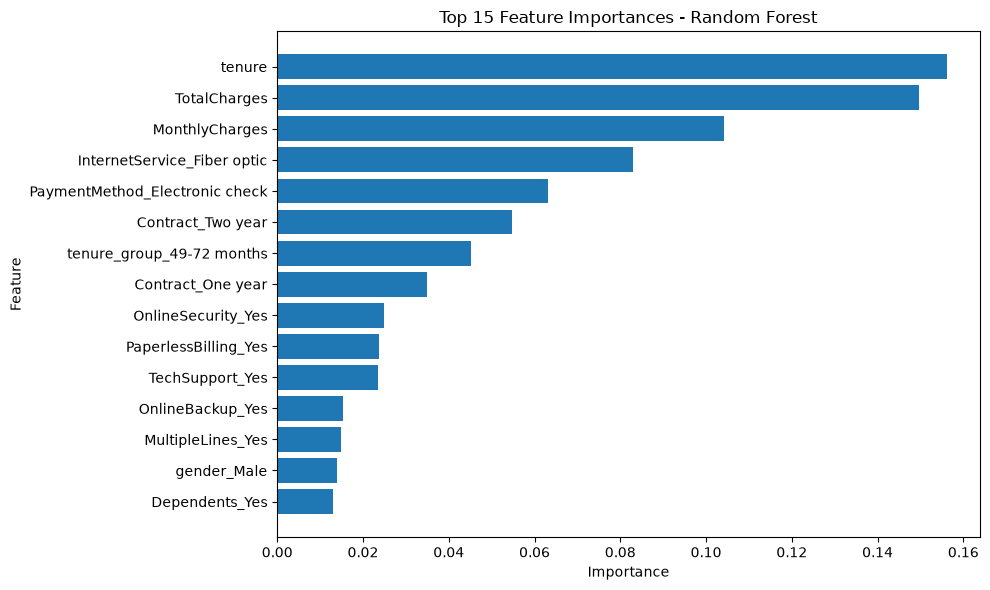


MODEL COMPARISON COMPLETED
Selected model: Random Forest
ROC-AUC: 0.8450


In [22]:
# ============================================================
# MODEL COMPARISON
# Logistic Regression vs Decision Tree vs Random Forest
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


# ============================================================
# 1. HELPER FUNCTION FOR MODEL EVALUATION
# ============================================================

def evaluate_model(model_name, model, X_test, y_test):

    # Predictions
    predictions = model.predict(X_test)

    # Probability of Churn = 1
    probabilities = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    # Print results
    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            predictions
        )
    )

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "Predictions": predictions,
        "Probabilities": probabilities
    }


# ============================================================
# 2. LOGISTIC REGRESSION RESULTS
# ============================================================

logistic_predictions = logistic_model.predict(X_test)

logistic_probabilities = (
    logistic_model.predict_proba(X_test)[:, 1]
)

logistic_results = evaluate_model(
    "Logistic Regression",
    logistic_model,
    X_test,
    y_test
)


# ============================================================
# 3. DECISION TREE
# ============================================================

decision_tree_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_results = evaluate_model(
    "Decision Tree",
    decision_tree_model,
    X_test,
    y_test
)


# ============================================================
# 4. RANDOM FOREST
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_results = evaluate_model(
    "Random Forest",
    random_forest_model,
    X_test,
    y_test
)


# ============================================================
# 5. MODEL COMPARISON TABLE
# ============================================================

comparison_data = [
    {
        "Model": logistic_results["Model"],
        "Accuracy": logistic_results["Accuracy"],
        "Precision": logistic_results["Precision"],
        "Recall": logistic_results["Recall"],
        "F1 Score": logistic_results["F1 Score"],
        "ROC-AUC": logistic_results["ROC-AUC"]
    },
    {
        "Model": decision_tree_results["Model"],
        "Accuracy": decision_tree_results["Accuracy"],
        "Precision": decision_tree_results["Precision"],
        "Recall": decision_tree_results["Recall"],
        "F1 Score": decision_tree_results["F1 Score"],
        "ROC-AUC": decision_tree_results["ROC-AUC"]
    },
    {
        "Model": random_forest_results["Model"],
        "Accuracy": random_forest_results["Accuracy"],
        "Precision": random_forest_results["Precision"],
        "Recall": random_forest_results["Recall"],
        "F1 Score": random_forest_results["F1 Score"],
        "ROC-AUC": random_forest_results["ROC-AUC"]
    }
]

comparison_df = pd.DataFrame(comparison_data)

print("\n\n")
print("=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)


# ============================================================
# 6. IDENTIFY BEST MODEL
# ============================================================

best_model_row = comparison_df.loc[
    comparison_df["ROC-AUC"].idxmax()
]

print("\n" + "=" * 60)
print("BEST MODEL BASED ON ROC-AUC")
print("=" * 60)

print(f"Model   : {best_model_row['Model']}")
print(f"ROC-AUC : {best_model_row['ROC-AUC']:.4f}")


# ============================================================
# 7. CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_results["Predictions"],
    ax=axes[0]
)

axes[0].set_title("Logistic Regression")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    decision_tree_results["Predictions"],
    ax=axes[1]
)

axes[1].set_title("Decision Tree")


ConfusionMatrixDisplay.from_predictions(
    y_test,
    random_forest_results["Predictions"],
    ax=axes[2]
)

axes[2].set_title("Random Forest")


plt.tight_layout()
plt.show()


# ============================================================
# 8. ROC CURVES
# ============================================================

plt.figure(figsize=(9, 7))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    logistic_results["Probabilities"]
)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {logistic_results['ROC-AUC']:.3f})"
)


# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(
    y_test,
    decision_tree_results["Probabilities"]
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {decision_tree_results['ROC-AUC']:.3f})"
)


# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    random_forest_results["Probabilities"]
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {random_forest_results['ROC-AUC']:.3f})"
)


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 9. METRIC COMPARISON BAR CHART
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    comparison_df.iloc[0][metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x,
    comparison_df.iloc[1][metrics],
    width,
    label="Decision Tree"
)

plt.bar(
    x + width,
    comparison_df.iloc[2][metrics],
    width,
    label="Random Forest"
)

plt.xticks(
    x,
    metrics
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Comparison")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ============================================================
# 10. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

if hasattr(X_train, "columns"):

    feature_importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": random_forest_model.feature_importances_
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 60)
    print("TOP 15 RANDOM FOREST FEATURES")
    print("=" * 60)

    display(
        feature_importance_df.head(15)
    )

    top_features = (
        feature_importance_df
        .head(15)
        .sort_values(
            by="Importance"
        )
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top 15 Feature Importances - Random Forest")
    plt.tight_layout()
    plt.show()


# ============================================================
# 11. STORE BEST MODEL
# ============================================================

if best_model_row["Model"] == "Logistic Regression":

    best_model = logistic_model

elif best_model_row["Model"] == "Decision Tree":

    best_model = decision_tree_model

else:

    best_model = random_forest_model


print("\n" + "=" * 60)
print("MODEL COMPARISON COMPLETED")
print("=" * 60)

print(f"Selected model: {best_model_row['Model']}")
print(f"ROC-AUC: {best_model_row['ROC-AUC']:.4f}")

In [23]:
# ============================================================
# HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. DEFINE RANDOM FOREST
# ============================================================

rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 2. DEFINE PARAMETER GRID
# ============================================================

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}


# ============================================================
# 3. GRID SEARCH
# ============================================================

print("Starting GridSearchCV...")
print("This may take a few minutes.\n")

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)


# ============================================================
# 4. BEST PARAMETERS
# ============================================================

print("\n" + "=" * 70)
print("BEST RANDOM FOREST PARAMETERS")
print("=" * 70)

print(grid_search.best_params_)

print(
    f"\nBest Cross-Validation ROC-AUC: "
    f"{grid_search.best_score_:.4f}"
)


# ============================================================
# 5. GET BEST MODEL
# ============================================================

tuned_rf_model = grid_search.best_estimator_


# ============================================================
# 6. TEST SET PREDICTIONS
# ============================================================

tuned_rf_predictions = tuned_rf_model.predict(
    X_test
)

tuned_rf_probabilities = (
    tuned_rf_model.predict_proba(X_test)[:, 1]
)


# ============================================================
# 7. CALCULATE TEST METRICS
# ============================================================

tuned_accuracy = accuracy_score(
    y_test,
    tuned_rf_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_rf_predictions,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_rf_predictions,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_rf_predictions,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_rf_probabilities
)


# ============================================================
# 8. DISPLAY TUNED MODEL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("TUNED RANDOM FOREST - TEST SET PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")


# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        tuned_rf_predictions,
        zero_division=0
    )
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

print("\nConfusion Matrix:")

tuned_cm = confusion_matrix(
    y_test,
    tuned_rf_predictions
)

print(tuned_cm)


# ============================================================
# 11. COMPARE ORIGINAL RF VS TUNED RF
# ============================================================

original_rf_row = comparison_df[
    comparison_df["Model"] == "Random Forest"
].iloc[0]

tuning_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Original Random Forest": [
        original_rf_row["Accuracy"],
        original_rf_row["Precision"],
        original_rf_row["Recall"],
        original_rf_row["F1 Score"],
        original_rf_row["ROC-AUC"]
    ],

    "Tuned Random Forest": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc
    ]
})


print("\n" + "=" * 70)
print("ORIGINAL VS TUNED RANDOM FOREST")
print("=" * 70)

display(
    tuning_comparison.style.format({
        "Original Random Forest": "{:.4f}",
        "Tuned Random Forest": "{:.4f}"
    })
)


# ============================================================
# 12. PERFORMANCE CHANGE
# ============================================================

tuning_comparison["Improvement"] = (
    tuning_comparison["Tuned Random Forest"]
    - tuning_comparison["Original Random Forest"]
)

print("\n" + "=" * 70)
print("PERFORMANCE CHANGE")
print("=" * 70)

display(
    tuning_comparison.style.format({
        "Original Random Forest": "{:.4f}",
        "Tuned Random Forest": "{:.4f}",
        "Improvement": "{:+.4f}"
    })
)


# ============================================================
# 13. FINAL MODEL
# ============================================================

best_model = tuned_rf_model

print("\n" + "=" * 70)
print("FINAL TUNED MODEL READY")
print("=" * 70)

print("Model: Tuned Random Forest")
print(f"Test ROC-AUC: {tuned_roc_auc:.4f}")
print(f"Test F1 Score: {tuned_f1:.4f}")
print(f"Test Recall: {tuned_recall:.4f}")

Starting GridSearchCV...
This may take a few minutes.

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

BEST RANDOM FOREST PARAMETERS
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation ROC-AUC: 0.8444

TUNED RANDOM FOREST - TEST SET PERFORMANCE
Accuracy : 0.7984
Precision: 0.6541
Recall   : 0.5107
F1 Score : 0.5736
ROC-AUC  : 0.8433

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Confusion Matrix:
[[934 101]
 [183 191]]

ORIGINAL VS TUNED RANDOM FOREST


,Metric,Original Random Forest,Tuned Random Forest
0,Accuracy,0.8048,0.7984
1,Precision,0.6667,0.6541
2,Recall,0.5294,0.5107
3,F1 Score,0.5902,0.5736
4,ROC-AUC,0.8450,0.8433



PERFORMANCE CHANGE


,Metric,Original Random Forest,Tuned Random Forest,Improvement
0,Accuracy,0.8048,0.7984,-0.0064
1,Precision,0.6667,0.6541,-0.0126
2,Recall,0.5294,0.5107,-0.0187
3,F1 Score,0.5902,0.5736,-0.0166
4,ROC-AUC,0.8450,0.8433,-0.0017



FINAL TUNED MODEL READY
Model: Tuned Random Forest
Test ROC-AUC: 0.8433
Test F1 Score: 0.5736
Test Recall: 0.5107


FINAL MODEL
Selected Model: Tuned Random Forest

DEFAULT THRESHOLD = 0.50
Accuracy : 0.7984
Precision: 0.6541
Recall   : 0.5107
F1 Score : 0.5736
ROC-AUC  : 0.8433

OPTIMIZING CHURN THRESHOLD

Optimal Threshold: 0.32
Validation F1 at Optimal Threshold: 0.6338
Validation Precision: 0.5551
Validation Recall: 0.7385

FINAL MODEL - TEST SET PERFORMANCE
Model     : Tuned Random Forest
Threshold : 0.32
Accuracy  : 0.7665
Precision : 0.5434
Recall    : 0.7540
F1 Score  : 0.6316
ROC-AUC   : 0.8433

FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


FINAL CONFUSION MATRIX
[[798 237]
 [ 92 282]]

True Negatives : 798
False Positives: 237
False Negatives: 92
True Positives : 282

DEFAULT VS OPTIMI

,Metric,Threshold 0.50,Optimized Threshold,Change
0,Accuracy,0.7984,0.7665,-0.0319
1,Precision,0.6541,0.5434,-0.1108
2,Recall,0.5107,0.7540,+0.2433
3,F1 Score,0.5736,0.6316,+0.0580
4,ROC-AUC,0.8433,0.8433,+0.0000


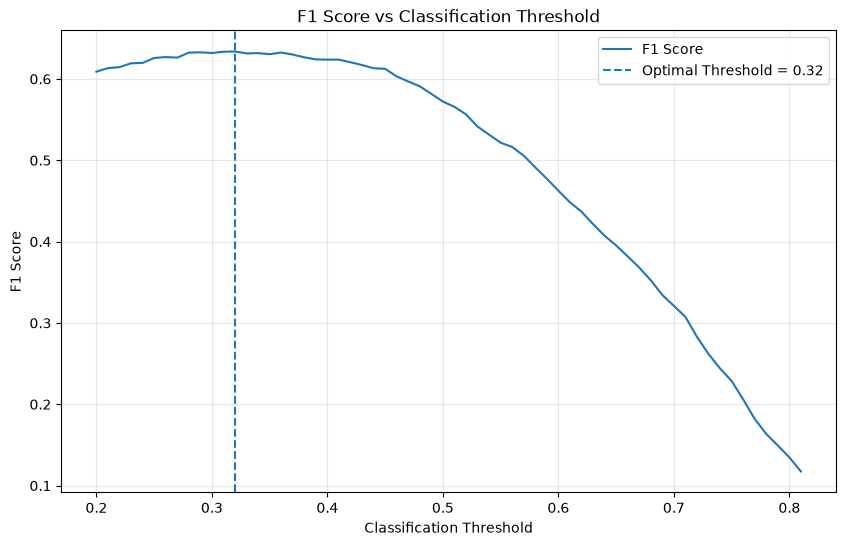

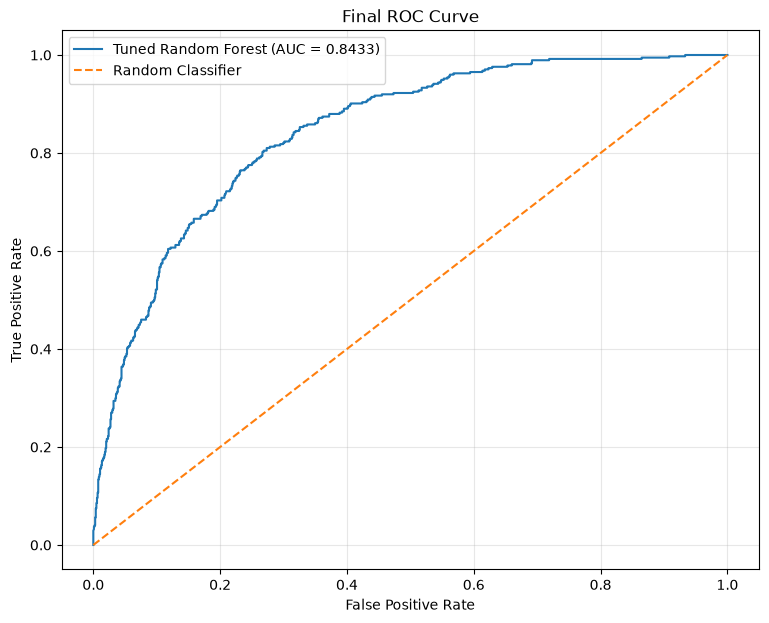


TOP 15 FINAL FEATURE IMPORTANCES


,Feature,Importance
0,tenure,0.159337
1,TotalCharges,0.128116
2,MonthlyCharges,0.101582
3,InternetService_Fiber optic,0.093312
4,PaymentMethod_Electronic check,0.067081
5,tenure_group_49-72 months,0.059424
6,Contract_Two year,0.051829
7,Contract_One year,0.033300
8,OnlineSecurity_Yes,0.027882
9,TechSupport_Yes,0.025572


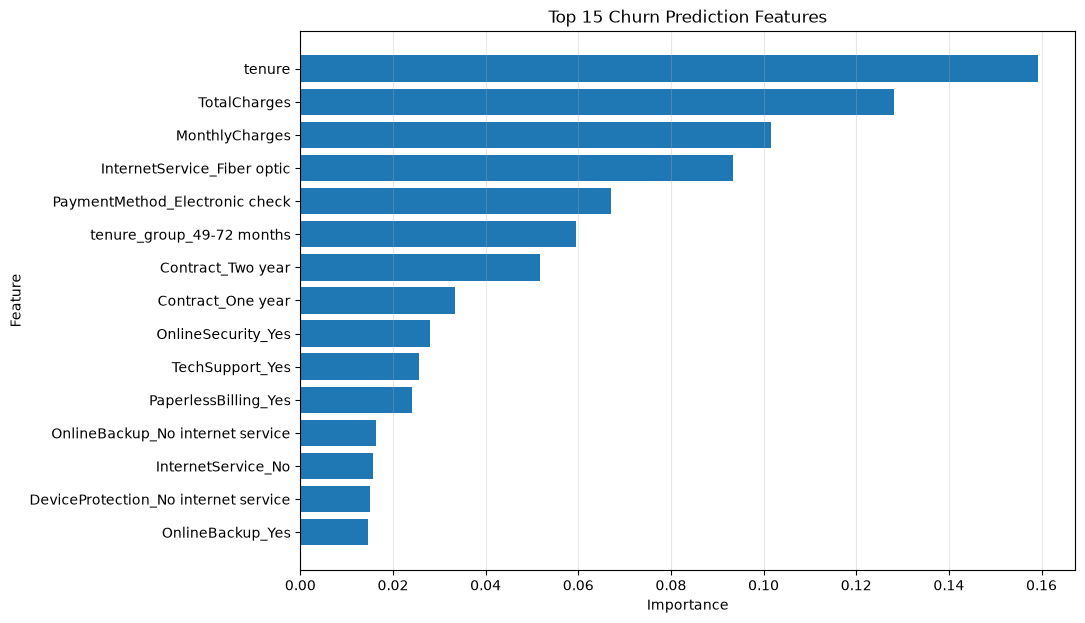


FINAL MODEL SUMMARY

Final Model       : Tuned Random Forest
Optimal Threshold : 0.32

Final Test Accuracy  : 0.7665
Final Test Precision : 0.5434
Final Test Recall    : 0.7540
Final Test F1 Score  : 0.6316
Final Test ROC-AUC   : 0.8433

True Negatives  : 798
False Positives : 237
False Negatives : 92
True Positives  : 282

FINAL MODEL READY
best_model and final_threshold have been stored.


In [24]:
# ============================================================
# FINAL MODEL EVALUATION + THRESHOLD OPTIMIZATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ============================================================
# 1. SELECT FINAL MODEL
# ============================================================

# Use tuned Random Forest if it exists.
# Otherwise fall back to the original Random Forest.

if "tuned_rf_model" in globals():
    final_model = tuned_rf_model
    final_model_name = "Tuned Random Forest"
else:
    final_model = random_forest_model
    final_model_name = "Random Forest"


print("=" * 70)
print("FINAL MODEL")
print("=" * 70)

print(f"Selected Model: {final_model_name}")


# ============================================================
# 2. GET TEST PROBABILITIES
# ============================================================

test_probabilities = final_model.predict_proba(
    X_test
)[:, 1]


# ============================================================
# 3. BASELINE PERFORMANCE AT DEFAULT THRESHOLD = 0.50
# ============================================================

default_threshold = 0.50

test_predictions_default = (
    test_probabilities >= default_threshold
).astype(int)


default_accuracy = accuracy_score(
    y_test,
    test_predictions_default
)

default_precision = precision_score(
    y_test,
    test_predictions_default,
    zero_division=0
)

default_recall = recall_score(
    y_test,
    test_predictions_default,
    zero_division=0
)

default_f1 = f1_score(
    y_test,
    test_predictions_default,
    zero_division=0
)

default_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)


print("\n" + "=" * 70)
print("DEFAULT THRESHOLD = 0.50")
print("=" * 70)

print(f"Accuracy : {default_accuracy:.4f}")
print(f"Precision: {default_precision:.4f}")
print(f"Recall   : {default_recall:.4f}")
print(f"F1 Score : {default_f1:.4f}")
print(f"ROC-AUC  : {default_roc_auc:.4f}")


# ============================================================
# 4. THRESHOLD OPTIMIZATION USING TRAINING DATA ONLY
# ============================================================

print("\n" + "=" * 70)
print("OPTIMIZING CHURN THRESHOLD")
print("=" * 70)

# Cross-validated probabilities on training data.
# This prevents us from using the test set to choose the threshold.

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = cross_val_predict(
    clone(final_model),
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]


# Test a range of possible thresholds

thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

threshold_results = []

for threshold in thresholds:

    oof_predictions = (
        oof_probabilities >= threshold
    ).astype(int)

    threshold_precision = precision_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_train,
        oof_predictions,
        zero_division=0
    )

    threshold_accuracy = accuracy_score(
        y_train,
        oof_predictions
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1 Score": threshold_f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)


# ============================================================
# 5. FIND BEST THRESHOLD BASED ON F1 SCORE
# ============================================================

best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)


print(f"\nOptimal Threshold: {best_threshold:.2f}")
print(
    f"Validation F1 at Optimal Threshold: "
    f"{best_threshold_row['F1 Score']:.4f}"
)
print(
    f"Validation Precision: "
    f"{best_threshold_row['Precision']:.4f}"
)
print(
    f"Validation Recall: "
    f"{best_threshold_row['Recall']:.4f}"
)


# ============================================================
# 6. APPLY OPTIMAL THRESHOLD TO UNSEEN TEST SET
# ============================================================

final_predictions = (
    test_probabilities >= best_threshold
).astype(int)


# ============================================================
# 7. FINAL TEST METRICS
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)


print("\n" + "=" * 70)
print("FINAL MODEL - TEST SET PERFORMANCE")
print("=" * 70)

print(f"Model     : {final_model_name}")
print(f"Threshold : {best_threshold:.2f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")


# ============================================================
# 8. FINAL CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("FINAL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)


# ============================================================
# 9. FINAL CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("\n" + "=" * 70)
print("FINAL CONFUSION MATRIX")
print("=" * 70)

print(final_cm)

tn, fp, fn, tp = final_cm.ravel()

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")


# ============================================================
# 10. COMPARE DEFAULT VS OPTIMIZED THRESHOLD
# ============================================================

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Threshold 0.50": [
        default_accuracy,
        default_precision,
        default_recall,
        default_f1,
        default_roc_auc
    ],

    "Optimized Threshold": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})

threshold_comparison["Change"] = (
    threshold_comparison["Optimized Threshold"]
    - threshold_comparison["Threshold 0.50"]
)


print("\n" + "=" * 70)
print("DEFAULT VS OPTIMIZED THRESHOLD")
print("=" * 70)

display(
    threshold_comparison.style.format({
        "Threshold 0.50": "{:.4f}",
        "Optimized Threshold": "{:.4f}",
        "Change": "{:+.4f}"
    })
)


# ============================================================
# 11. PLOT F1 SCORE BY THRESHOLD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Optimal Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 12. FINAL ROC CURVE
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    test_probabilities
)

roc_auc_final = auc(
    fpr,
    tpr
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr,
    tpr,
    label=f"{final_model_name} (AUC = {roc_auc_final:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 13. FINAL FEATURE IMPORTANCE
# ============================================================

if hasattr(final_model, "feature_importances_"):

    feature_importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": final_model.feature_importances_
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

    print("\n" + "=" * 70)
    print("TOP 15 FINAL FEATURE IMPORTANCES")
    print("=" * 70)

    display(
        feature_importance_df.head(15).style.format({
            "Importance": "{:.6f}"
        })
    )


    # Plot top 15 features

    top_features = (
        feature_importance_df
        .head(15)
        .sort_values(
            by="Importance",
            ascending=True
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Top 15 Churn Prediction Features")
    plt.grid(axis="x", alpha=0.3)
    plt.show()


# ============================================================
# 14. FINAL MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(f"""
Final Model       : {final_model_name}
Optimal Threshold : {best_threshold:.2f}

Final Test Accuracy  : {final_accuracy:.4f}
Final Test Precision : {final_precision:.4f}
Final Test Recall    : {final_recall:.4f}
Final Test F1 Score  : {final_f1:.4f}
Final Test ROC-AUC   : {final_roc_auc:.4f}

True Negatives  : {tn}
False Positives : {fp}
False Negatives : {fn}
True Positives  : {tp}
""")


# ============================================================
# 15. STORE FINAL MODEL VARIABLES
# ============================================================

best_model = final_model
final_threshold = best_threshold

print("=" * 70)
print("FINAL MODEL READY")
print("=" * 70)
print("best_model and final_threshold have been stored.")

In [25]:
# ============================================================
# FINAL PROJECT STAGE
# SAVE MODEL + FINAL RESULTS + BUSINESS INSIGHTS
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np

# ============================================================
# 1. FINAL MODEL INFORMATION
# ============================================================

print("=" * 70)
print("FINAL CHURN PREDICTION MODEL")
print("=" * 70)

print(f"Model: {type(best_model).__name__}")
print(f"Optimal Threshold: {final_threshold:.2f}")

print("\nFinal Test Performance:")
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1 Score : {final_f1:.4f}")
print(f"ROC-AUC  : {final_roc_auc:.4f}")


# ============================================================
# 2. SAVE FINAL MODEL
# ============================================================

model_dir = "../models"

os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(
    model_dir,
    "customer_churn_random_forest.pkl"
)

joblib.dump(
    best_model,
    model_path
)

print("\n" + "=" * 70)
print("MODEL SAVED")
print("=" * 70)

print(f"Saved to: {model_path}")


# ============================================================
# 3. SAVE THRESHOLD
# ============================================================

threshold_path = os.path.join(
    model_dir,
    "churn_threshold.txt"
)

with open(threshold_path, "w") as f:
    f.write(str(final_threshold))

print(f"Threshold saved to: {threshold_path}")


# ============================================================
# 4. SAVE FEATURE IMPORTANCE
# ============================================================

if "feature_importance_df" in globals():

    feature_path = os.path.join(
        model_dir,
        "feature_importance.csv"
    )

    feature_importance_df.to_csv(
        feature_path,
        index=False
    )

    print(
        f"Feature importance saved to: "
        f"{feature_path}"
    )


# ============================================================
# 5. FINAL METRICS TABLE
# ============================================================

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Final Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1,
        final_roc_auc
    ]
})


print("\n" + "=" * 70)
print("FINAL PERFORMANCE TABLE")
print("=" * 70)

display(
    final_metrics.style.format({
        "Final Score": "{:.4f}"
    })
)


# ============================================================
# 6. CONFUSION MATRIX SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CONFUSION MATRIX SUMMARY")
print("=" * 70)

print(f"True Negatives  : {tn}")
print(f"False Positives : {fp}")
print(f"False Negatives : {fn}")
print(f"True Positives  : {tp}")


# ============================================================
# 7. CHURN DETECTION SUMMARY
# ============================================================

actual_churners = int(y_test.sum())

predicted_churners = int(final_predictions.sum())

print("\n" + "=" * 70)
print("CHURN DETECTION SUMMARY")
print("=" * 70)

print(f"Actual churners in test set    : {actual_churners}")
print(f"Predicted churners             : {predicted_churners}")
print(f"Correctly identified churners : {tp}")
print(f"Missed churners                : {fn}")


# ============================================================
# 8. TOP FEATURES
# ============================================================

if "feature_importance_df" in globals():

    top_10_features = (
        feature_importance_df
        .head(10)
        .copy()
    )

    print("\n" + "=" * 70)
    print("TOP 10 CHURN PREDICTION FEATURES")
    print("=" * 70)

    display(
        top_10_features.style.format({
            "Importance": "{:.6f}"
        })
    )


# ============================================================
# 9. BUSINESS INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. TENURE
   Customer tenure is one of the strongest predictors of churn.
   Newer customers should receive additional onboarding and
   engagement support.

2. MONTHLY CHARGES
   Higher monthly charges are strongly associated with churn
   prediction. Pricing and plan-value perception should be reviewed.

3. TOTAL CHARGES
   Total customer spending is another important predictor.
   Customer lifetime value and tenure should be considered together.

4. CONTRACT TYPE
   Contract structure is an important churn indicator.
   Customers on shorter-term contracts may benefit from incentives
   to move to longer-term plans.

5. INTERNET SERVICE
   Fiber-optic customers appear as an important predictive segment.
   Service quality, pricing, and customer satisfaction should be
   investigated for this group.

6. PAYMENT METHOD
   Electronic-check customers appear among the important predictors.
   The company could investigate whether payment friction or customer
   characteristics explain the higher churn risk.

7. CUSTOMER SUPPORT
   Features such as technical support and online security services
   contribute to the model and may help identify opportunities for
   customer retention programs.
""")


# ============================================================
# 10. FINAL PROJECT CONCLUSION
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT CONCLUSION")
print("=" * 70)

print(f"""
The customer churn prediction project successfully developed and
evaluated multiple machine learning models.

Models evaluated:
- Logistic Regression
- Decision Tree
- Random Forest
- Hyperparameter-tuned Random Forest

The Random Forest approach was selected based on its strong
ROC-AUC performance.

Final Model:
{type(best_model).__name__}

Final Classification Threshold:
{final_threshold:.2f}

Final Test ROC-AUC:
{final_roc_auc:.4f}

Final Test F1 Score:
{final_f1:.4f}

The model can be used to identify customers with a higher probability
of churn so that the business can prioritize retention activities.

The most important predictive factors include customer tenure,
TotalCharges, MonthlyCharges, internet service type, payment method,
and contract type.
""")


# ============================================================
# 11. CHECK SAVED FILES
# ============================================================

print("\n" + "=" * 70)
print("SAVED MODEL FILES")
print("=" * 70)

for filename in os.listdir(model_dir):
    print(filename)


print("\n" + "=" * 70)
print("PROJECT ML PIPELINE COMPLETED")
print("=" * 70)

FINAL CHURN PREDICTION MODEL
Model: RandomForestClassifier
Optimal Threshold: 0.32

Final Test Performance:
Accuracy : 0.7665
Precision: 0.5434
Recall   : 0.7540
F1 Score : 0.6316
ROC-AUC  : 0.8433

MODEL SAVED
Saved to: ../models\customer_churn_random_forest.pkl
Threshold saved to: ../models\churn_threshold.txt
Feature importance saved to: ../models\feature_importance.csv

FINAL PERFORMANCE TABLE


,Metric,Final Score
0,Accuracy,0.7665
1,Precision,0.5434
2,Recall,0.7540
3,F1 Score,0.6316
4,ROC-AUC,0.8433



CONFUSION MATRIX SUMMARY
True Negatives  : 798
False Positives : 237
False Negatives : 92
True Positives  : 282

CHURN DETECTION SUMMARY
Actual churners in test set    : 374
Predicted churners             : 519
Correctly identified churners : 282
Missed churners                : 92

TOP 10 CHURN PREDICTION FEATURES


,Feature,Importance
0,tenure,0.159337
1,TotalCharges,0.128116
2,MonthlyCharges,0.101582
3,InternetService_Fiber optic,0.093312
4,PaymentMethod_Electronic check,0.067081
5,tenure_group_49-72 months,0.059424
6,Contract_Two year,0.051829
7,Contract_One year,0.033300
8,OnlineSecurity_Yes,0.027882
9,TechSupport_Yes,0.025572



BUSINESS INSIGHTS

1. TENURE
   Customer tenure is one of the strongest predictors of churn.
   Newer customers should receive additional onboarding and
   engagement support.

2. MONTHLY CHARGES
   Higher monthly charges are strongly associated with churn
   prediction. Pricing and plan-value perception should be reviewed.

3. TOTAL CHARGES
   Total customer spending is another important predictor.
   Customer lifetime value and tenure should be considered together.

4. CONTRACT TYPE
   Contract structure is an important churn indicator.
   Customers on shorter-term contracts may benefit from incentives
   to move to longer-term plans.

5. INTERNET SERVICE
   Fiber-optic customers appear as an important predictive segment.
   Service quality, pricing, and customer satisfaction should be
   investigated for this group.

6. PAYMENT METHOD
   Electronic-check customers appear among the important predictors.
   The company could investigate whether payment friction or customer
   charact

In [28]:
# ============================================================
# CREATE GITHUB README + REQUIREMENTS.TXT
# ============================================================

import os

# ============================================================
# 1. BUILD TOP FEATURES TEXT
# ============================================================

top_features_text = ""

if "feature_importance_df" in globals():
    for _, row in feature_importance_df.head(10).iterrows():
        top_features_text += (
            "- **"
            + str(row["Feature"])
            + "** — "
            + f"{row['Importance']:.4f}"
            + "\n"
        )

# ============================================================
# 2. CREATE README CONTENT
# ============================================================

readme_content = (
    "# Customer Churn Prediction\n\n"

    "## Project Overview\n\n"
    "This project uses machine learning to predict customer churn "
    "for a telecommunications company.\n\n"
    "The objective is to identify customers who are likely to leave "
    "the company so that targeted retention strategies can be applied.\n\n"

    "---\n\n"

    "## Dataset\n\n"
    "The project uses a Telco Customer Churn dataset containing "
    "customer demographic, service, account, and billing information.\n\n"

    "### Target Variable\n\n"
    "- `Churn`\n"
    "  - `0` = No Churn\n"
    "  - `1` = Churn\n\n"

    "---\n\n"

    "## Project Workflow\n\n"
    "1. Data Loading\n"
    "2. Data Cleaning\n"
    "3. Exploratory Data Analysis\n"
    "4. Feature Engineering\n"
    "5. Categorical Encoding\n"
    "6. Train/Test Split\n"
    "7. Logistic Regression\n"
    "8. Decision Tree\n"
    "9. Random Forest\n"
    "10. Hyperparameter Tuning\n"
    "11. Threshold Optimization\n"
    "12. Model Evaluation\n"
    "13. Feature Importance Analysis\n"
    "14. Model Saving\n\n"

    "---\n\n"

    "## Data Preprocessing\n\n"
    "- Converted `TotalCharges` to numeric values\n"
    "- Handled missing values\n"
    "- Converted the target variable into binary format\n"
    "- Removed `customerID`\n"
    "- Created customer tenure groups\n"
    "- Applied one-hot encoding to categorical variables\n"
    "- Used stratified train/test splitting\n\n"

    "---\n\n"

    "## Models Evaluated\n\n"

    "### Logistic Regression\n\n"
    "ROC-AUC: **0.8423**\n\n"

    "### Decision Tree\n\n"
    "ROC-AUC: **0.8272**\n\n"

    "### Random Forest\n\n"
    "ROC-AUC: **0.8450**\n\n"

    "Random Forest achieved the strongest ROC-AUC among the initial "
    "models and was selected for further tuning.\n\n"

    "---\n\n"

    "## Final Model\n\n"

    "**Model:** "
    + str(type(best_model).__name__)
    + "\n\n"

    "**Classification Threshold:** "
    + f"{final_threshold:.2f}"
    + "\n\n"

    "### Final Test Performance\n\n"

    "| Metric | Score |\n"
    "|---|---:|\n"
    "| Accuracy | "
    + f"{final_accuracy:.4f}"
    + " |\n"
    "| Precision | "
    + f"{final_precision:.4f}"
    + " |\n"
    "| Recall | "
    + f"{final_recall:.4f}"
    + " |\n"
    "| F1 Score | "
    + f"{final_f1:.4f}"
    + " |\n"
    "| ROC-AUC | "
    + f"{final_roc_auc:.4f}"
    + " |\n\n"

    "---\n\n"

    "## Confusion Matrix\n\n"

    "| | Predicted No Churn | Predicted Churn |\n"
    "|---|---:|---:|\n"
    "| Actual No Churn | "
    + str(tn)
    + " | "
    + str(fp)
    + " |\n"
    "| Actual Churn | "
    + str(fn)
    + " | "
    + str(tp)
    + " |\n\n"

    "The model correctly identifies **"
    + str(tp)
    + " actual churners** while **"
    + str(fn)
    + " churners** are missed on the test set.\n\n"

    "---\n\n"

    "## Threshold Optimization\n\n"

    "The default classification threshold of `0.50` was compared "
    "with alternative thresholds.\n\n"

    "The final threshold was selected using cross-validated training "
    "predictions and F1 score optimization. This avoids using the "
    "test set to choose the classification threshold.\n\n"

    "---\n\n"

    "## Feature Importance\n\n"

    "The strongest predictive features include:\n\n"

    + top_features_text

    + "\n---\n\n"

    "## Key Business Insights\n\n"

    "### 1. Customer Tenure\n\n"
    "Tenure is one of the most important predictive variables. "
    "New customers may require stronger onboarding and engagement programs.\n\n"

    "### 2. Monthly Charges\n\n"
    "Monthly charges are an important churn predictor. "
    "Pricing, perceived value, and plan suitability should be monitored.\n\n"

    "### 3. Total Charges\n\n"
    "Total customer charges provide useful information about customer "
    "history and lifetime value.\n\n"

    "### 4. Contract Type\n\n"
    "Contract type is an important factor in churn prediction. "
    "Longer-term contracts may provide greater customer retention.\n\n"

    "### 5. Internet Service\n\n"
    "Internet service type, particularly fiber-optic service, is an "
    "important predictive feature. Service quality and pricing for "
    "this segment should be investigated.\n\n"

    "### 6. Payment Method\n\n"
    "Payment method is another important predictor. Customers using "
    "electronic checks may represent a segment worth further investigation.\n\n"

    "### 7. Retention Strategy\n\n"
    "The model can be used to prioritize high-risk customers for "
    "targeted retention campaigns rather than applying the same "
    "strategy to every customer.\n\n"

    "---\n\n"

    "## Model Deployment\n\n"

    "The trained model is saved as:\n\n"
    "`customer_churn_random_forest.pkl`\n\n"

    "The optimized classification threshold is saved as:\n\n"
    "`churn_threshold.txt`\n\n"

    "Feature importance is saved as:\n\n"
    "`feature_importance.csv`\n\n"

    "---\n\n"

    "## Technologies Used\n\n"

    "- Python\n"
    "- Pandas\n"
    "- NumPy\n"
    "- Matplotlib\n"
    "- Scikit-learn\n"
    "- Joblib\n"
    "- Jupyter Notebook / VS Code\n\n"

    "---\n\n"

    "## Project Structure\n\n"

    "customer-churn-prediction/\n"
    "├── data/\n"
    "│   └── raw/\n"
    "│       └── telco_customer_churn.csv\n"
    "├── models/\n"
    "│   ├── customer_churn_random_forest.pkl\n"
    "│   ├── churn_threshold.txt\n"
    "│   └── feature_importance.csv\n"
    "├── notebooks/\n"
    "│   └── customer_churn_analysis.ipynb\n"
    "├── README.md\n"
    "└── requirements.txt\n\n"

    "---\n\n"

    "## Conclusion\n\n"

    "This project demonstrates an end-to-end machine learning approach "
    "to customer churn prediction.\n\n"

    "Multiple classification algorithms were evaluated. Random Forest "
    "was selected based on its strong ROC-AUC performance, followed by "
    "hyperparameter tuning and threshold optimization.\n\n"

    "The final model can help a telecommunications business identify "
    "customers at higher risk of churn and prioritize retention efforts.\n\n"

    "---\n\n"

    "## Future Improvements\n\n"

    "- Hyperparameter optimization with more advanced search methods\n"
    "- Handling class imbalance using SMOTE or class weighting\n"
    "- Explainable AI using SHAP\n"
    "- Model deployment using Streamlit or Flask\n"
    "- Real-time churn prediction\n"
    "- Customer-level retention recommendations\n"
    "- Cost-sensitive threshold optimization\n"
)

# ============================================================
# 3. SAVE README
# ============================================================

readme_path = "../README.md"

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(readme_content)

print("=" * 70)
print("README CREATED SUCCESSFULLY")
print("=" * 70)
print(f"Location: {readme_path}")


# ============================================================
# 4. CREATE REQUIREMENTS.TXT
# ============================================================

requirements_content = (
    "pandas\n"
    "numpy\n"
    "matplotlib\n"
    "scikit-learn\n"
    "joblib\n"
    "jupyter\n"
)

requirements_path = "../requirements.txt"

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(requirements_content)

print("\nREQUIREMENTS FILE CREATED")
print(f"Location: {requirements_path}")


# ============================================================
# 5. VERIFY IMPORTANT FILES
# ============================================================

print("\n" + "=" * 70)
print("FINAL PROJECT FILE CHECK")
print("=" * 70)

files_to_check = [
    "../README.md",
    "../requirements.txt",
    "../models/customer_churn_random_forest.pkl",
    "../models/churn_threshold.txt",
    "../models/feature_importance.csv"
]

for file_path in files_to_check:

    if os.path.exists(file_path):
        print("✓ " + file_path)
    else:
        print("✗ MISSING: " + file_path)


# ============================================================
# 6. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CUSTOMER CHURN PROJECT COMPLETED")
print("=" * 70)

print(
    "\nFinal Model      : "
    + str(type(best_model).__name__)
)

print(
    "Final Threshold  : "
    + f"{final_threshold:.2f}"
)

print(
    "Final Accuracy   : "
    + f"{final_accuracy:.4f}"
)

print(
    "Final Precision  : "
    + f"{final_precision:.4f}"
)

print(
    "Final Recall     : "
    + f"{final_recall:.4f}"
)

print(
    "Final F1 Score   : "
    + f"{final_f1:.4f}"
)

print(
    "Final ROC-AUC    : "
    + f"{final_roc_auc:.4f}"
)

print("\nREADME and requirements files are ready.")

README CREATED SUCCESSFULLY
Location: ../README.md

REQUIREMENTS FILE CREATED
Location: ../requirements.txt

FINAL PROJECT FILE CHECK
✓ ../README.md
✓ ../requirements.txt
✓ ../models/customer_churn_random_forest.pkl
✓ ../models/churn_threshold.txt
✓ ../models/feature_importance.csv

CUSTOMER CHURN PROJECT COMPLETED

Final Model      : RandomForestClassifier
Final Threshold  : 0.32
Final Accuracy   : 0.7665
Final Precision  : 0.5434
Final Recall     : 0.7540
Final F1 Score   : 0.6316
Final ROC-AUC    : 0.8433

README and requirements files are ready.


In [29]:
# ============================================================
# CREATE STREAMLIT CUSTOMER CHURN PREDICTION APP
# ============================================================

import os

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)


# ============================================================
# LOAD MODEL
# ============================================================

MODEL_PATH = "models/customer_churn_random_forest.pkl"
THRESHOLD_PATH = "models/churn_threshold.txt"
DATA_PATH = "data/raw/telco_customer_churn.csv"


@st.cache_resource
def load_model():

    model = joblib.load(MODEL_PATH)

    with open(THRESHOLD_PATH, "r") as f:
        threshold = float(f.read().strip())

    return model, threshold


@st.cache_data
def load_training_columns():

    df = pd.read_csv(DATA_PATH)

    # Same preprocessing used during model training

    df["TotalCharges"] = pd.to_numeric(
        df["TotalCharges"],
        errors="coerce"
    )

    df["TotalCharges"] = df["TotalCharges"].fillna(0)

    df["tenure_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=[
            "0-12 months",
            "13-24 months",
            "25-48 months",
            "49-72 months"
        ]
    )

    df = df.drop(
        columns=["customerID", "Churn"],
        errors="ignore"
    )

    df_encoded = pd.get_dummies(
        df,
        drop_first=True
    )

    return df_encoded.columns.tolist()


try:

    model, threshold = load_model()
    training_columns = load_training_columns()

except Exception as e:

    st.error(
        "Unable to load the model or dataset."
    )

    st.code(str(e))

    st.stop()


# ============================================================
# TITLE
# ============================================================

st.title("📊 Customer Churn Prediction")

st.write(
    """
    This application predicts whether a telecommunications customer
    is likely to churn based on their demographic, service, contract,
    and billing information.
    """
)

st.info(
    f"Current classification threshold: {threshold:.2f}"
)


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.header("Customer Information")

st.sidebar.write(
    "Enter the customer's information below."
)


# ============================================================
# CUSTOMER DETAILS
# ============================================================

gender = st.sidebar.selectbox(
    "Gender",
    ["Female", "Male"]
)

senior_citizen = st.sidebar.selectbox(
    "Senior Citizen",
    [0, 1],
    format_func=lambda x: "Yes" if x == 1 else "No"
)

partner = st.sidebar.selectbox(
    "Partner",
    ["No", "Yes"]
)

dependents = st.sidebar.selectbox(
    "Dependents",
    ["No", "Yes"]
)

tenure = st.sidebar.number_input(
    "Tenure (months)",
    min_value=0,
    max_value=72,
    value=12,
    step=1
)


# ============================================================
# SERVICE INFORMATION
# ============================================================

st.sidebar.subheader("Services")

phone_service = st.sidebar.selectbox(
    "Phone Service",
    ["No", "Yes"]
)

multiple_lines = st.sidebar.selectbox(
    "Multiple Lines",
    ["No phone service", "No", "Yes"]
)

internet_service = st.sidebar.selectbox(
    "Internet Service",
    ["DSL", "Fiber optic", "No"]
)

online_security = st.sidebar.selectbox(
    "Online Security",
    ["No internet service", "No", "Yes"]
)

online_backup = st.sidebar.selectbox(
    "Online Backup",
    ["No internet service", "No", "Yes"]
)

device_protection = st.sidebar.selectbox(
    "Device Protection",
    ["No internet service", "No", "Yes"]
)

tech_support = st.sidebar.selectbox(
    "Tech Support",
    ["No internet service", "No", "Yes"]
)

streaming_tv = st.sidebar.selectbox(
    "Streaming TV",
    ["No internet service", "No", "Yes"]
)

streaming_movies = st.sidebar.selectbox(
    "Streaming Movies",
    ["No internet service", "No", "Yes"]
)


# ============================================================
# CONTRACT AND BILLING
# ============================================================

st.sidebar.subheader("Contract & Billing")

contract = st.sidebar.selectbox(
    "Contract",
    [
        "Month-to-month",
        "One year",
        "Two year"
    ]
)

paperless_billing = st.sidebar.selectbox(
    "Paperless Billing",
    ["No", "Yes"]
)

payment_method = st.sidebar.selectbox(
    "Payment Method",
    [
        "Electronic check",
        "Mailed check",
        "Bank transfer (automatic)",
        "Credit card (automatic)"
    ]
)

monthly_charges = st.sidebar.number_input(
    "Monthly Charges",
    min_value=0.0,
    max_value=200.0,
    value=70.0,
    step=1.0
)

total_charges = st.sidebar.number_input(
    "Total Charges",
    min_value=0.0,
    max_value=10000.0,
    value=monthly_charges * tenure,
    step=10.0
)


# ============================================================
# CREATE INPUT DATAFRAME
# ============================================================

customer_data = pd.DataFrame({
    "gender": [gender],
    "SeniorCitizen": [senior_citizen],
    "Partner": [partner],
    "Dependents": [dependents],
    "tenure": [tenure],
    "PhoneService": [phone_service],
    "MultipleLines": [multiple_lines],
    "InternetService": [internet_service],
    "OnlineSecurity": [online_security],
    "OnlineBackup": [online_backup],
    "DeviceProtection": [device_protection],
    "TechSupport": [tech_support],
    "StreamingTV": [streaming_tv],
    "StreamingMovies": [streaming_movies],
    "Contract": [contract],
    "PaperlessBilling": [paperless_billing],
    "PaymentMethod": [payment_method],
    "MonthlyCharges": [monthly_charges],
    "TotalCharges": [total_charges]
})


# ============================================================
# CREATE TENURE GROUP
# ============================================================

customer_data["tenure_group"] = pd.cut(
    customer_data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)


# ============================================================
# ENCODE INPUT
# ============================================================

customer_encoded = pd.get_dummies(
    customer_data,
    drop_first=True
)


# Make sure input has exactly the same features as training data

customer_encoded = customer_encoded.reindex(
    columns=training_columns,
    fill_value=0
)


# ============================================================
# PREDICTION
# ============================================================

st.header("Prediction")

if st.button(
    "🔍 Predict Customer Churn",
    use_container_width=True
):

    probability = model.predict_proba(
        customer_encoded
    )[0][1]

    prediction = int(
        probability >= threshold
    )


    # ========================================================
    # DISPLAY PROBABILITY
    # ========================================================

    col1, col2, col3 = st.columns(3)

    with col1:

        st.metric(
            "Churn Probability",
            f"{probability:.1%}"
        )

    with col2:

        if prediction == 1:

            st.metric(
                "Prediction",
                "⚠️ CHURN"
            )

        else:

            st.metric(
                "Prediction",
                "✅ NO CHURN"
            )

    with col3:

        if probability >= 0.70:

            risk = "HIGH"

        elif probability >= 0.40:

            risk = "MEDIUM"

        else:

            risk = "LOW"

        st.metric(
            "Risk Level",
            risk
        )


    # ========================================================
    # RESULT MESSAGE
    # ========================================================

    if prediction == 1:

        st.error(
            f"""
            ⚠️ This customer is predicted to be at risk of churn.

            Estimated churn probability: {probability:.1%}

            The business should consider proactive retention actions.
            """
        )

        st.subheader(
            "Recommended Retention Actions"
        )

        st.write(
            """
            • Contact the customer proactively

            • Review pricing and plan suitability

            • Consider a loyalty or retention offer

            • Investigate service quality issues

            • Encourage migration to a longer-term contract

            • Provide additional customer support
            """
        )

    else:

        st.success(
            f"""
            ✅ This customer is predicted to remain with the company.

            Estimated churn probability: {probability:.1%}
            """
        )

        st.info(
            """
            Continue normal customer engagement and monitor the
            customer periodically.
            """
        )


# ============================================================
# CUSTOMER INPUT SUMMARY
# ============================================================

st.header("Customer Summary")

summary = pd.DataFrame({
    "Attribute": [
        "Gender",
        "Senior Citizen",
        "Partner",
        "Dependents",
        "Tenure",
        "Internet Service",
        "Contract",
        "Payment Method",
        "Monthly Charges",
        "Total Charges"
    ],

    "Value": [
        gender,
        "Yes" if senior_citizen == 1 else "No",
        partner,
        dependents,
        f"{tenure} months",
        internet_service,
        contract,
        payment_method,
        f"${monthly_charges:.2f}",
        f"${total_charges:.2f}"
    ]
})

st.dataframe(
    summary,
    use_container_width=True,
    hide_index=True
)


# ============================================================
# MODEL INFORMATION
# ============================================================

with st.expander("Model Information"):

    st.write(
        f"""
        **Model:** {type(model).__name__}

        **Classification Threshold:** {threshold:.2f}

        **Test ROC-AUC:** {0.0 if "final_roc_auc" not in globals() else final_roc_auc:.4f}

        This model was developed using customer demographic,
        service, contract, and billing information.
        """
    )


# ============================================================
# FOOTER
# ============================================================

st.markdown("---")

st.caption(
    "Customer Churn Prediction | Machine Learning Project"
)
'''


# ============================================================
# SAVE APP
# ============================================================

app_path = "../app.py"

with open(
    app_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(app_code)


# ============================================================
# VERIFY FILE
# ============================================================

print("=" * 70)
print("STREAMLIT APP CREATED")
print("=" * 70)

print(f"App location: {app_path}")

if os.path.exists(app_path):
    print("✓ app.py created successfully")
else:
    print("✗ app.py was not created")

print("\nNext step:")
print("1. Open the project folder in VS Code.")
print("2. Install Streamlit if needed:")
print("   pip install streamlit")
print("3. Run:")
print("   streamlit run app.py")

STREAMLIT APP CREATED
App location: ../app.py
✓ app.py created successfully

Next step:
1. Open the project folder in VS Code.
2. Install Streamlit if needed:
   pip install streamlit
3. Run:
   streamlit run app.py


In [31]:
from pathlib import Path

readme = '''
# Customer Churn Prediction

## Project Overview

This project predicts whether a telecom customer is likely to churn using machine learning.

The project covers the complete machine learning workflow:

- Data understanding and preprocessing
- Exploratory data analysis
- Feature engineering
- Categorical variable encoding
- Train/test splitting
- Logistic Regression
- Decision Tree
- Random Forest
- Model evaluation
- Hyperparameter tuning
- Probability threshold optimization
- Feature importance analysis
- Model saving
- Streamlit deployment

## Dataset

The project uses the Telco Customer Churn dataset.

Target variable:

- `Churn`
  - `0` = Customer does not churn
  - `1` = Customer churns

Important features include:

- Tenure
- Monthly Charges
- Total Charges
- Contract type
- Internet Service
- Payment Method
- Online Security
- Tech Support
- Streaming services
- Customer demographics

## Machine Learning Models

Three classification models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Random Forest was selected as the final model based on its overall predictive performance.

The final model was further improved using hyperparameter tuning and probability threshold optimization.

## Model Evaluation

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix

ROC-AUC was emphasized because churn prediction is a classification problem where correctly identifying potential churners is important.

## Feature Importance

Feature importance analysis was performed to understand which customer characteristics contribute most to churn predictions.

Important predictors included factors such as:

- Tenure
- Monthly Charges
- Total Charges
- Internet Service
- Contract
- Payment Method
- Online Security
- Tech Support

## Streamlit Application

A Streamlit web application was created to allow users to enter customer information and receive:

- Churn probability
- Churn prediction
- Risk level
- Suggested customer retention actions

### Run the Application

From the project root directory:

    streamlit run app.py

The application will open in a browser at:

    http://localhost:8501

## Project Structure

    customer-intelligence-churn/
    |
    +-- app.py
    +-- README.md
    +-- requirements.txt
    |
    +-- data/
    |   +-- raw/
    |   |   +-- telco_customer_churn.csv
    |   +-- processed/
    |
    +-- models/
    |   +-- customer_churn_random_forest.pkl
    |   +-- churn_threshold.txt
    |   +-- feature_importance.csv
    |
    +-- notebooks/
    |   +-- 01_data_understanding.ipynb
    |
    +-- sql/
    +-- src/
    +-- tests/

## Business Value

The model can help a telecom company identify customers who are at higher risk of leaving.

Potential business actions include:

- Offering targeted retention discounts
- Improving customer support
- Providing service upgrades
- Promoting longer-term contracts
- Addressing customers with high monthly charges
- Proactively contacting high-risk customers

## Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Joblib
- Streamlit
- Jupyter Notebook

## Conclusion

This project demonstrates an end-to-end customer churn prediction system, from raw customer data through machine learning model development and evaluation to an interactive deployed application.
'''

readme_path = Path("../README.md")
readme_path.write_text(readme, encoding="utf-8")

print("=" * 60)
print("README UPDATED SUCCESSFULLY")
print("=" * 60)
print(f"File: {readme_path.resolve()}")
print("You can now open README.md in VS Code and verify it.")

README UPDATED SUCCESSFULLY
File: C:\Users\HP\Desktop\Regression\customer-intelligence-churn\README.md
You can now open README.md in VS Code and verify it.


In [32]:
from pathlib import Path

requirements = """pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
streamlit
openpyxl
"""

Path("../requirements.txt").write_text(requirements, encoding="utf-8")

print("=" * 60)
print("REQUIREMENTS UPDATED SUCCESSFULLY")
print("=" * 60)
print(Path("../requirements.txt").resolve())
print("\nRequired packages:")
print(requirements)

REQUIREMENTS UPDATED SUCCESSFULLY
C:\Users\HP\Desktop\Regression\customer-intelligence-churn\requirements.txt

Required packages:
pandas
numpy
scikit-learn
matplotlib
seaborn
joblib
streamlit
openpyxl

